# 05 - SHAP Explainability

Interpret the tuned XGBoost model using SHAP (SHapley Additive exPlanations).
Every plot is saved to `outputs/figures/` and prefixed `05_`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load model and test data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler           = StandardScaler()
scaler.fit(X_train)
X_test_scaled    = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

model = joblib.load(MODELS_PATH / 'best_xgb.pkl')
print(f'Model       : {type(model).__name__}')
print(f'Test samples: {X_test_scaled_df.shape[0]:,}')
print(f'Fraud cases : {y_test.sum()}')

Model       : XGBClassifier
Test samples: 56,962
Fraud cases : 98


## 2. SHAP TreeExplainer

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled_df)

print(f'shap_values shape : {shap_values.shape}')
print(f'Expected value    : {explainer.expected_value:.4f}')

shap_values shape : (56962, 30)
Expected value    : 4.7366


## 3. Global summary - bar chart

Mean absolute SHAP value per feature across all test transactions.

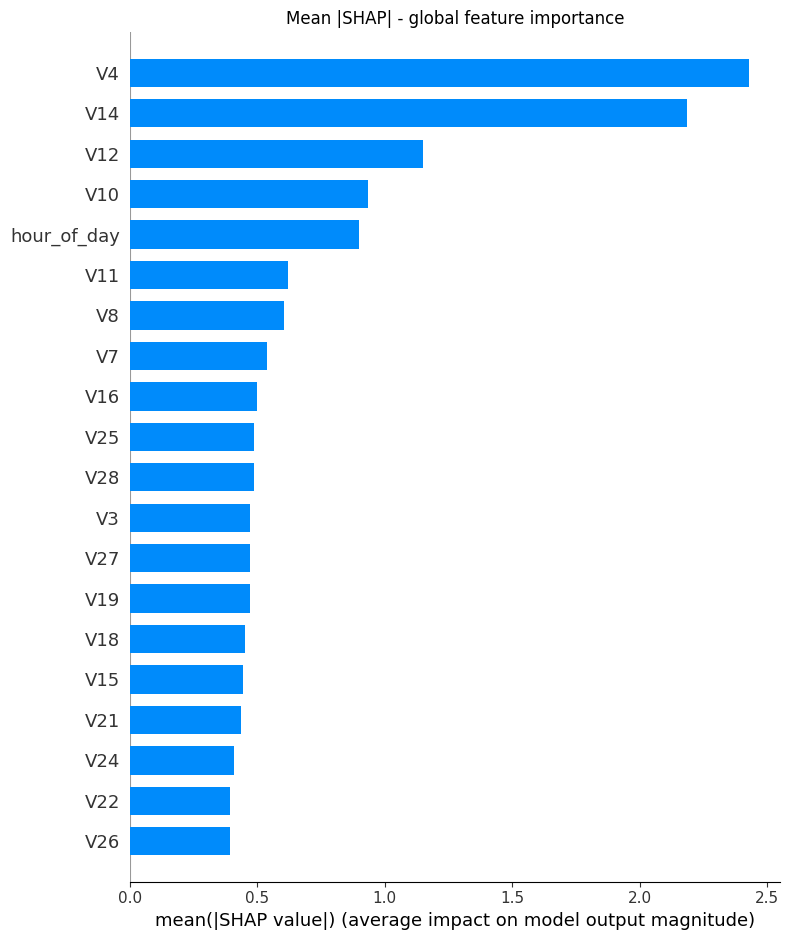

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled_df, plot_type='bar', show=False)
plt.title('Mean |SHAP| - global feature importance')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Beeswarm - feature effect direction

Each dot is one transaction. Colour = feature value; x-axis = impact on model output.

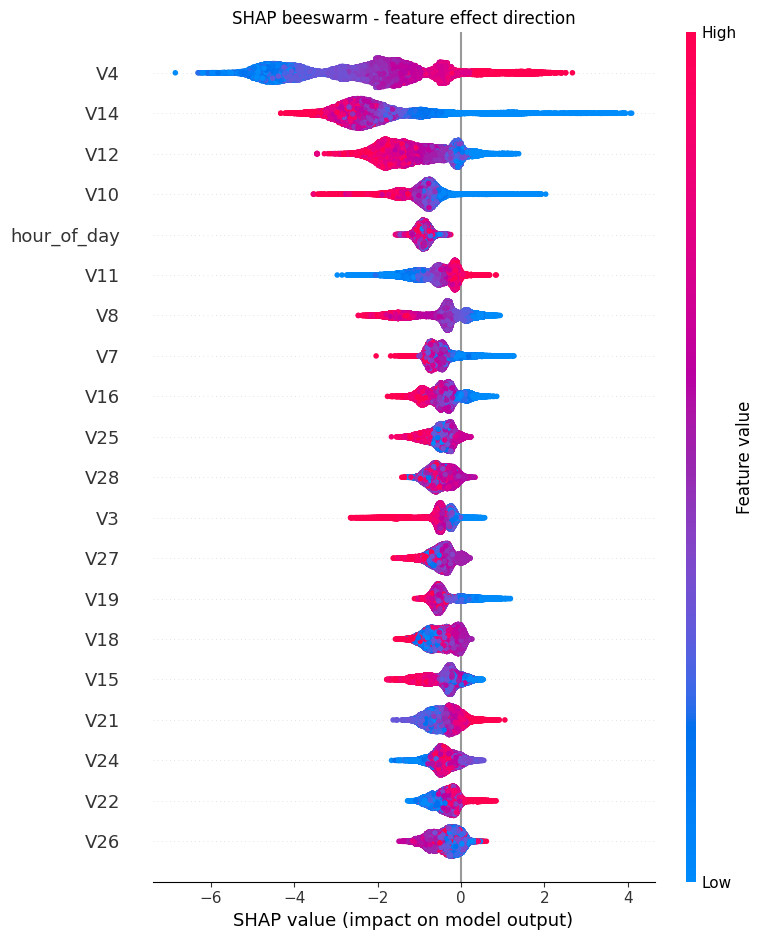

In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title('SHAP beeswarm - feature effect direction')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Waterfall - single fraud prediction

Breaks down one fraud transaction into per-feature contributions.

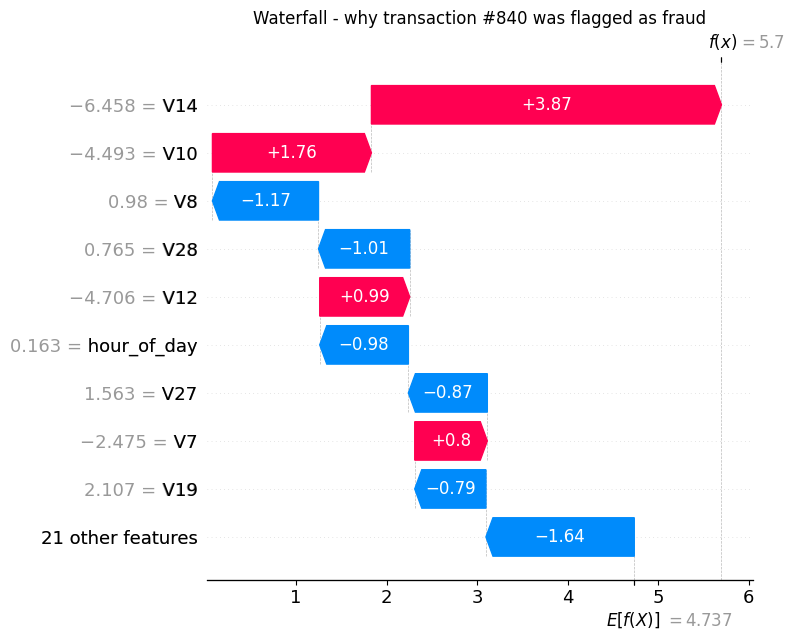

In [6]:
fraud_indices = np.where(y_test.values == 1)[0]
idx           = fraud_indices[0]

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_values[idx],
        base_values  = explainer.expected_value,
        data         = X_test_scaled_df.iloc[idx],
        feature_names= X_test_scaled_df.columns.tolist(),
    ),
    show=False,
)
plt.title(f'Waterfall - why transaction #{idx} was flagged as fraud')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Force plot - first 50 test samples

Interactive HTML force plot saved to disk.

In [7]:
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[:50],
    X_test_scaled_df.iloc[:50],
    show=False,
)
shap.save_html(str(FIGURES_PATH / '05_shap_force_plot.html'), force_plot)
print('Saved: outputs/figures/05_shap_force_plot.html')

Saved: outputs/figures/05_shap_force_plot.html


## 7. Mean |SHAP| feature ranking

Top 10 features by mean |SHAP|:
V4             2.429436
V14            2.185755
V12            1.148785
V10            0.933847
hour_of_day    0.897824
V11            0.621437
V8             0.604276
V7             0.538504
V16            0.501332
V25            0.488286


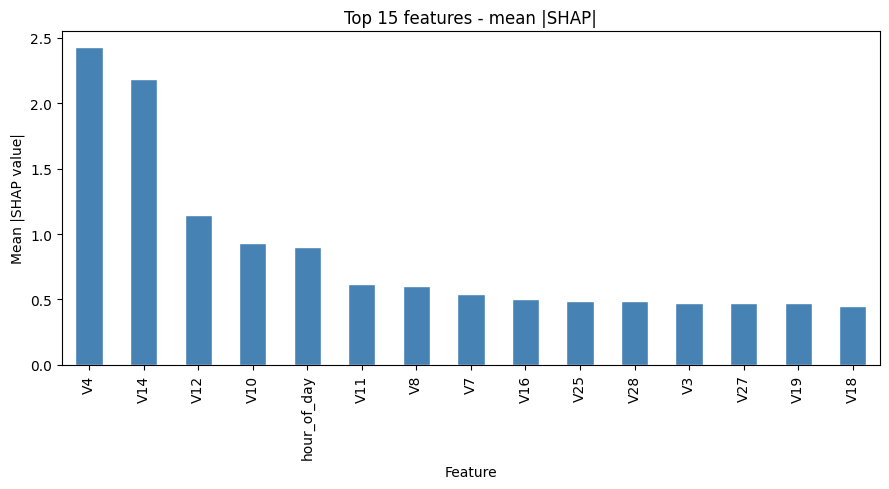

In [8]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_scaled_df.columns
).sort_values(ascending=False)

print('Top 10 features by mean |SHAP|:')
print(mean_shap.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
mean_shap.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 features - mean |SHAP|')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_shap_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Dependence plot - V14

Shows the relationship between V14 values and fraud risk.

<Figure size 1000x600 with 0 Axes>

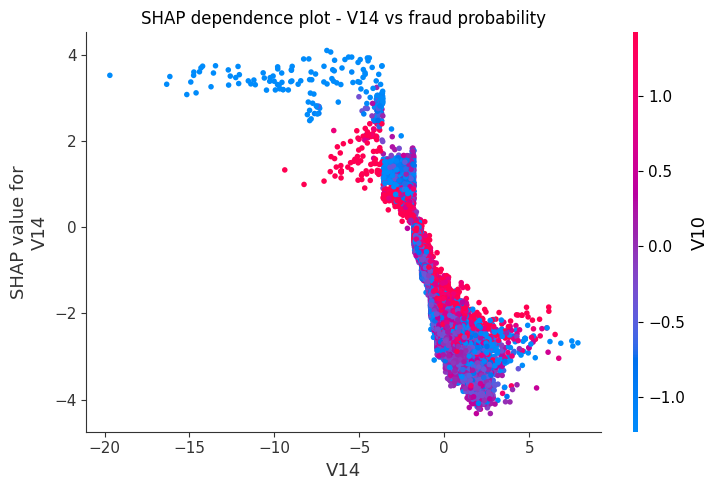

In [9]:
plt.figure(figsize=(10, 6))
shap.dependence_plot('V14', shap_values, X_test_scaled_df, show=False)
plt.title('SHAP dependence plot - V14 vs fraud probability')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_shap_dependence_v14.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

In [10]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_scaled_df.columns
).sort_values(ascending=False)

print('=== SHAP GLOBAL SUMMARY ===')
print('\nTop 5 fraud signals:')
for feat, score in mean_shap.head(5).items():
    print(f'  {feat:15s}  mean |SHAP|: {score:.4f}')

print('\nNext: notebook 06 - threshold tuning')
print('At what fraud probability do we block a transaction?')

=== SHAP GLOBAL SUMMARY ===

Top 5 fraud signals:
  V4               mean |SHAP|: 2.4294
  V14              mean |SHAP|: 2.1858
  V12              mean |SHAP|: 1.1488
  V10              mean |SHAP|: 0.9338
  hour_of_day      mean |SHAP|: 0.8978

Next: notebook 06 - threshold tuning
At what fraud probability do we block a transaction?
